# Sales Rep Agent
A sales rep agent which can send email automatically to person, and can also act as a virtual twin to reply to emails on your behalf.

In [1]:
from dotenv import load_dotenv
import requests
from agents import Agent, Runner, trace, function_tool, ModelSettings
from agents.extensions.visualization import draw_graph
from openai.types.responses import ResponseTextDeltaEvent
import os
import asyncio
import smtplib
from email.message import EmailMessage
load_dotenv(override=True)
MODEL_NAME = "gpt-5.4-nano"

## Set Up GMAIL

In [2]:
EMAIL_ADDRESS = os.getenv("EMAIL_ADDRESS")
EMAIL_SMTP_SERVER = os.getenv("EMAIL_SMTP_SERVER")
EMAIL_APP_PASSWORD = os.getenv("EMAIL_APP_PASSWORD")

## Set Up Pushover Notification as a Fallback Strategy

In [3]:
pushover_user = os.getenv("PUSHOVER_USER")
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_url = "https://api.pushover.net/1/messages.json"

In [4]:
@function_tool
def send_email_notification(subject: str, text_body: str, html_body: str = None):
    msg = EmailMessage()
    msg["From"] = EMAIL_ADDRESS
    msg["To"] = "debanjang0.dg@gmail.com"
    msg["Subject"] = subject
    msg.set_content(text_body)
    if html_body:
        msg.add_alternative(html_body, subtype="html")

    with smtplib.SMTP(EMAIL_SMTP_SERVER, 587) as server:
        server.starttls()
        server.login(EMAIL_ADDRESS, EMAIL_APP_PASSWORD)
        server.send_message(msg)

    payload = {"user": pushover_user, "token": pushover_token, "message": text_body, "title": subject}
    requests.post(url=pushover_url, data=payload)

In [12]:
send_email_notification("Test Email", "This is a test email notification from the assistant.")

In [5]:
instructions = """
You are an sales agent. You work for a real estate based Saas company RealEstatePro, which provides Saas based solution for small and medium house owner.
Your job is to send email to leads to convince them to use your product. You have to write a convincing email to the lead, highlighting the benefits of using RealEstatePro and how it can help them manage their properties more efficiently. Make sure to personalize the email based on the lead's information and include a call-to-action for them to sign up for a free trial or schedule a demo.

Your email writing style is professional and serious.

Your task:
1. Generate the email.
2. Send the email.
""".strip()

In [7]:
sales_agent = Agent(name="SalesAgent", model=MODEL_NAME, instructions=instructions, tools=[send_email_notification])

In [8]:
message = "Send a sales email"

with trace("Sales email workflow"):
    results = await Runner.run(sales_agent, message)
    print(results.final_output)

with trace("Sales email workflow"):
    results = Runner.run_streamed(sales_agent, message)
    async for event in results.stream_events():
        if event.type == "raw_response_event" and isinstance(event.data, ResponseTextDeltaEvent):
            print(event.data.delta, end="", flush=True)

Subject: Simplify your property management with RealEstatePro (Free Trial)

Hi {{FirstName}},  

I noticed you’re a homeowner/landlord managing {{PropertyCount}} {{PropertyType}}(s). If you’re juggling tenants, rent tracking, maintenance requests, documents, and reminders, you’re probably spending more time on admin than on your property goals.

RealEstatePro is a SaaS platform designed for small and medium property owners to help you:
- **Centralize property data** (leases, documents, inspections, and notes) in one place  
- **Track rent and payments** with clear status and automated reminders  
- **Streamline maintenance requests** and keep a complete history of issues and work orders  
- **Stay organized with scheduled tasks** so nothing gets missed  
- **Save time** with a workflow built specifically for owner-managed portfolios  

If you’d like, I can show you how it would work for your properties in a quick 15-minute demo.

**Would you prefer to start a free trial or schedule a d

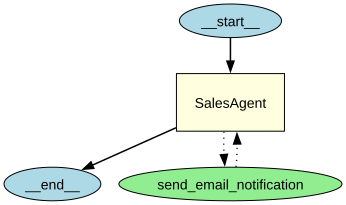

In [9]:
draw_graph(sales_agent)